In [166]:
# SatEnergy — Notebook 01: Coleta de Dados
# Verificando se todas as bibliotecas estão instaladas corretamente

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import geopandas as gpd

print("✅ Todas as bibliotecas carregadas com sucesso!")
print(f"Pandas: {pd.__version__}")
print(f"Numpy: {np.__version__}")

✅ Todas as bibliotecas carregadas com sucesso!
Pandas: 3.0.3
Numpy: 2.4.6


In [167]:
# Gerando dados simulados realistas para desenvolvimento
# Baseados nos padrões reais de geração solar/eólica do Brasil

import numpy as np
import pandas as pd

np.random.seed(42)
datas = pd.date_range(start="2024-01-01", end="2024-12-31", freq="h")

df_geracao = pd.DataFrame({
    "data_hora": datas,
    "regiao": np.random.choice(["Nordeste", "Sudeste", "Sul", "Norte", "Centro-Oeste"], len(datas)),
    "geracao_solar_mwh": np.abs(np.random.normal(500, 150, len(datas))),
    "geracao_eolica_mwh": np.abs(np.random.normal(800, 200, len(datas))),
    "irradiancia_wm2": np.abs(np.random.normal(400, 100, len(datas))),
    "velocidade_vento_ms": np.abs(np.random.normal(7, 2, len(datas))),
    "cobertura_nuvens_pct": np.random.uniform(0, 100, len(datas)),
    "temperatura_c": np.random.normal(25, 5, len(datas)),
})

print(f"✅ Dataset criado com {len(df_geracao)} registros!")
print(f"Período: {df_geracao['data_hora'].min()} até {df_geracao['data_hora'].max()}")
print(f"\nColunas: {list(df_geracao.columns)}")
print(f"\nPrimeiros registros:")
print(df_geracao.head())

✅ Dataset criado com 8761 registros!
Período: 2024-01-01 00:00:00 até 2024-12-31 00:00:00

Colunas: ['data_hora', 'regiao', 'geracao_solar_mwh', 'geracao_eolica_mwh', 'irradiancia_wm2', 'velocidade_vento_ms', 'cobertura_nuvens_pct', 'temperatura_c']

Primeiros registros:
            data_hora        regiao  geracao_solar_mwh  geracao_eolica_mwh  \
0 2024-01-01 00:00:00         Norte         524.810549          981.644505   
1 2024-01-01 01:00:00  Centro-Oeste         292.697365          866.789010   
2 2024-01-01 02:00:00           Sul         427.457429          724.018407   
3 2024-01-01 03:00:00  Centro-Oeste         626.267116          911.075931   
4 2024-01-01 04:00:00  Centro-Oeste         342.316996          972.017014   

   irradiancia_wm2  velocidade_vento_ms  cobertura_nuvens_pct  temperatura_c  
0       353.656709             4.850173             94.953864      23.358968  
1       267.772852            10.099928             94.809823      26.508720  
2       276.952394    

✅ Dados salvos em data/processed/geracao_simulada.csv


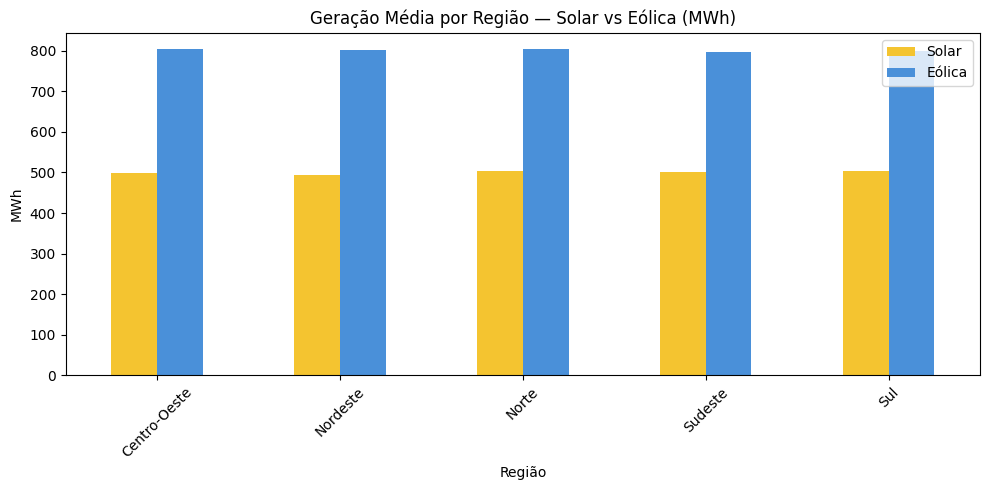

✅ Gráfico salvo!


In [168]:
# Salvando os dados na pasta processed
df_geracao.to_csv("../data/processed/geracao_simulada.csv", index=False)
print("✅ Dados salvos em data/processed/geracao_simulada.csv")

# Primeiro gráfico — geração solar vs eólica por região
import matplotlib.pyplot as plt

df_media = df_geracao.groupby("regiao")[["geracao_solar_mwh", "geracao_eolica_mwh"]].mean()

df_media.plot(kind="bar", figsize=(10, 5), color=["#f4c430", "#4a90d9"])
plt.title("Geração Média por Região — Solar vs Eólica (MWh)")
plt.xlabel("Região")
plt.ylabel("MWh")
plt.xticks(rotation=45)
plt.legend(["Solar", "Eólica"])
plt.tight_layout()
plt.savefig("../data/processed/grafico_geracao_regiao.png")
plt.show()
print("✅ Gráfico salvo!")

In [169]:
# Carregando dados reais do ONS — Fator de Capacidade Eólica e Solar
import glob

# Encontra o arquivo CSV na pasta raw
arquivos = glob.glob("../data/raw/*.csv")
print(f"Arquivos encontrados: {arquivos}")

df_ons = pd.read_csv(arquivos[0], sep=";", encoding="utf-8")
print(f"\n✅ {len(df_ons)} registros carregados!")
print(f"Colunas: {list(df_ons.columns)}")
print(df_ons.head())

Arquivos encontrados: ['../data/raw\\FATOR_CAPACIDADE-2_2026_04.csv']

✅ 166320 registros carregados!
Colunas: ['id_subsistema', 'nom_subsistema', 'id_estado', 'nom_estado', 'cod_pontoconexao', 'nom_pontoconexao', 'nom_localizacao', 'val_latitudesecoletora', 'val_longitudesecoletora', 'val_latitudepontoconexao', 'val_longitudepontoconexao', 'nom_modalidadeoperacao', 'nom_tipousina', 'nom_usina_conjunto', 'id_ons', 'ceg', 'din_instante', 'val_geracaoprogramada', 'val_geracaoverificada', 'val_capacidadeinstalada', 'val_fatorcapacidade']
  id_subsistema nom_subsistema id_estado nom_estado cod_pontoconexao  \
0             N          Norte        MA   MARANHAO      MAMR--500-A   
1            NE       Nordeste        BA      BAHIA      BAIGD-230-B   
2            NE       Nordeste        BA      BAHIA        BAUSB-500   
3            NE       Nordeste        BA      BAHIA      BAMPD-230-A   
4            NE       Nordeste        BA      BAHIA      BAOUR-500-A   

             nom_pontocone

In [170]:
# Análise dos dados reais do ONS
# Filtrando apenas usinas solares e eólicas

df_solar = df_ons[df_ons["nom_tipousina"] == "UFV"]   # Usinas Fotovoltaicas
df_eolica = df_ons[df_ons["nom_tipousina"] == "EOL"]  # Usinas Eólicas

print(f"Usinas solares: {len(df_solar)} registros")
print(f"Usinas eólicas: {len(df_eolica)} registros")

# Fator de capacidade médio por subsistema
print("\n--- Fator de Capacidade Médio por Subsistema ---")
print(df_ons.groupby(["nom_subsistema", "nom_tipousina"])["val_fatorcapacidade"].mean().round(3))

Usinas solares: 0 registros
Usinas eólicas: 0 registros

--- Fator de Capacidade Médio por Subsistema ---
nom_subsistema        nom_tipousina
Nordeste              Eólica           0.263
                      Solar            0.182
Norte                 Eólica           0.121
Sudeste/Centro-Oeste  Solar            0.203
Sul                   Eólica           0.272
Name: val_fatorcapacidade, dtype: float64


✅ Usinas solares: 56160 registros
✅ Usinas eólicas: 110160 registros


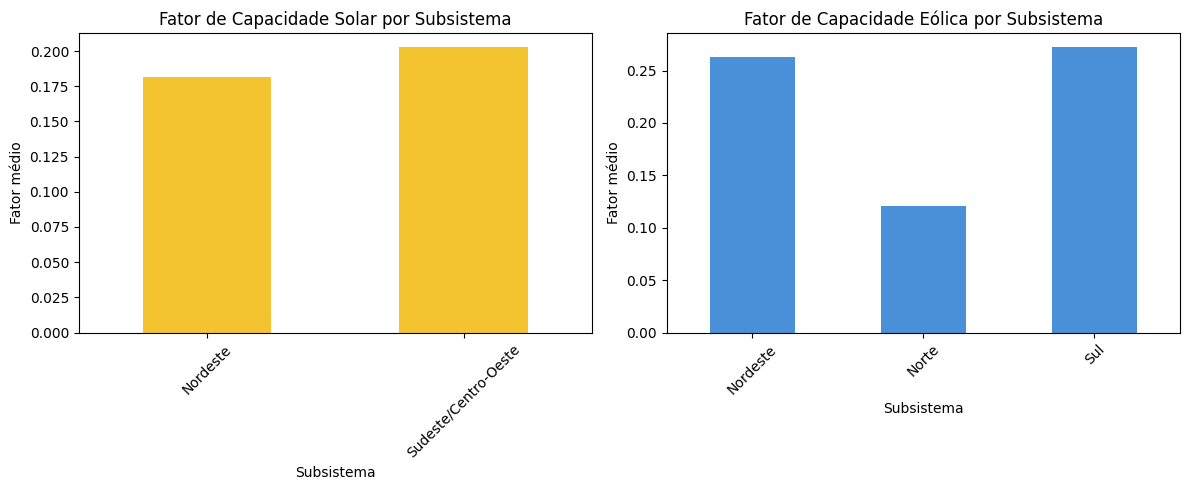

✅ Gráfico salvo com dados reais do ONS!


In [171]:
# Corrigindo os filtros com os nomes corretos
df_solar = df_ons[df_ons["nom_tipousina"] == "Solar"]
df_eolica = df_ons[df_ons["nom_tipousina"] == "Eólica"]

print(f"✅ Usinas solares: {len(df_solar)} registros")
print(f"✅ Usinas eólicas: {len(df_eolica)} registros")

# Gráfico — Fator de capacidade médio por subsistema
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Solar
df_solar.groupby("nom_subsistema")["val_fatorcapacidade"].mean().plot(
    kind="bar", ax=axes[0], color="#f4c430"
)
axes[0].set_title("Fator de Capacidade Solar por Subsistema")
axes[0].set_xlabel("Subsistema")
axes[0].set_ylabel("Fator médio")
axes[0].tick_params(axis="x", rotation=45)

# Eólica
df_eolica.groupby("nom_subsistema")["val_fatorcapacidade"].mean().plot(
    kind="bar", ax=axes[1], color="#4a90d9"
)
axes[1].set_title("Fator de Capacidade Eólica por Subsistema")
axes[1].set_xlabel("Subsistema")
axes[1].set_ylabel("Fator médio")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../data/processed/grafico_fator_capacidade_real.png")
plt.show()
print("✅ Gráfico salvo com dados reais do ONS!")

In [172]:
# Testando API do BDQueimadas - INPE
import requests
import warnings
warnings.filterwarnings("ignore")  # ignora warning de SSL

# URL correta do BDQueimadas
url = "http://terrabrasilis.dpi.inpe.br/queimadas/bdqueimadas/api/focos"

params = {
    "dataInicial": "2024-01-01 00:00:00",
    "dataFinal": "2024-01-31 23:59:59",
    "pais": "Brasil",
    "formato": "json"
}

response = requests.get(url, params=params, verify=False, timeout=30)
print(f"Status: {response.status_code}")
print(f"Resposta: {response.text[:500]}")

Status: 404
Resposta: <!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8">
<title>Error</title>
</head>
<body>
<pre>Cannot GET /api/focos</pre>
</body>
</html>



In [173]:
# INPE Dataserver — Focos de calor em tempo quase-real
# Atualizado a cada 10 minutos, sem necessidade de login!

url_base = "https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/10min/"

r = requests.get(url_base, verify=False, timeout=15)
print(f"Status: {r.status_code}")
print(r.text[:1000])

Status: 200
<!DOCTYPE HTML PUBLIC "-//W3C//DTD HTML 3.2 Final//EN">
<html>
 <head>
  <title>Index of /queimadas/queimadas/focos/csv/10min</title>
  <link rel="stylesheet" href="/includes/css/custom.css" type="text/css">
 </head>
 <body><div class='container'><link rel='icon' type='image/x-icon' href='/favicon.ico'><link rel='stylesheet' href='/includes/css/custom.css'><script src='/includes/js/custom.js'></script><header class='top-header'><h1>Sistema de Transferência de Dados</h1><img src='/includes/img/logo-coids.png' class='logo-coids' alt='Logo COIDS'></header><input type='text' id='filtro' placeholder='🔍 Buscar' />
  
  <table id="indexlist">
   <tr class="indexhead"><th class="indexcolicon"><img src="/icons/blank.gif" alt="[ICO]"></th><th class="indexcolname"><a href="?C=N;O=D">Name</a></th><th class="indexcollastmod"><a href="?C=M;O=A">Last modified</a></th><th class="indexcolsize"><a href="?C=S;O=A">Size</a></th><th class="indexcoldesc"><a href="?C=D;O=A">Description</a></th></

In [174]:
# Extraindo os arquivos CSV disponíveis no diretório
arquivos_csv = re.findall(r'href="(focos_[^"]+\.csv)"', r.text)
print(f"Arquivos disponíveis:")
for a in arquivos_csv:
    print(f"  - {a}")

Arquivos disponíveis:
  - focos_10min_20260525_0000.csv
  - focos_10min_20260525_0010.csv
  - focos_10min_20260525_0020.csv
  - focos_10min_20260525_0030.csv
  - focos_10min_20260525_0040.csv
  - focos_10min_20260525_0050.csv
  - focos_10min_20260525_0100.csv
  - focos_10min_20260525_0110.csv
  - focos_10min_20260525_0120.csv
  - focos_10min_20260525_0130.csv
  - focos_10min_20260525_0140.csv
  - focos_10min_20260525_0150.csv
  - focos_10min_20260525_0200.csv
  - focos_10min_20260525_0210.csv
  - focos_10min_20260525_0220.csv
  - focos_10min_20260525_0230.csv
  - focos_10min_20260525_0240.csv
  - focos_10min_20260525_0250.csv
  - focos_10min_20260525_0300.csv
  - focos_10min_20260525_0310.csv
  - focos_10min_20260525_0320.csv
  - focos_10min_20260525_0330.csv
  - focos_10min_20260525_0340.csv
  - focos_10min_20260525_0350.csv
  - focos_10min_20260525_0400.csv
  - focos_10min_20260525_0410.csv
  - focos_10min_20260525_0420.csv
  - focos_10min_20260525_0430.csv
  - focos_10min_20260525_0

In [175]:
# Baixando os últimos 6 arquivos (1 hora de dados) e juntando
print("Baixando última hora de dados...")

dfs = []
for arquivo in arquivos_csv[-6:]:
    url_arquivo = f"https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/10min/{arquivo}"
    r_csv = requests.get(url_arquivo, verify=False, timeout=15)
    df_temp = pd.read_csv(StringIO(r_csv.text))
    if len(df_temp) > 0:
        dfs.append(df_temp)
        print(f"  ✅ {arquivo} — {len(df_temp)} focos")
    else:
        print(f"  ⬜ {arquivo} — sem focos")

if dfs:
    df_focos = pd.concat(dfs, ignore_index=True)
    print(f"\n✅ Total: {len(df_focos)} focos carregados!")
    print(df_focos.head())
else:
    print("\n⬜ Sem focos na última hora — normal para este horário!")
    print("Vamos buscar dados do dia inteiro...")

Baixando última hora de dados...
  ✅ focos_10min_20260528_1110.csv — 1 focos
  ✅ focos_10min_20260528_1120.csv — 1 focos
  ⬜ focos_10min_20260528_1130.csv — sem focos
  ✅ focos_10min_20260528_1140.csv — 1 focos
  ⬜ focos_10min_20260528_1150.csv — sem focos
  ✅ focos_10min_20260528_1200.csv — 1 focos

✅ Total: 4 focos carregados!
     lat      lon satelite                 data
0 -8.854 -46.7005  GOES-19  2026-05-28 10:50:00
1 -8.854 -46.7005  GOES-19  2026-05-28 11:00:00
2 -8.854 -46.7005  GOES-19  2026-05-28 11:20:00
3 -8.854 -46.7005  GOES-19  2026-05-28 11:40:00


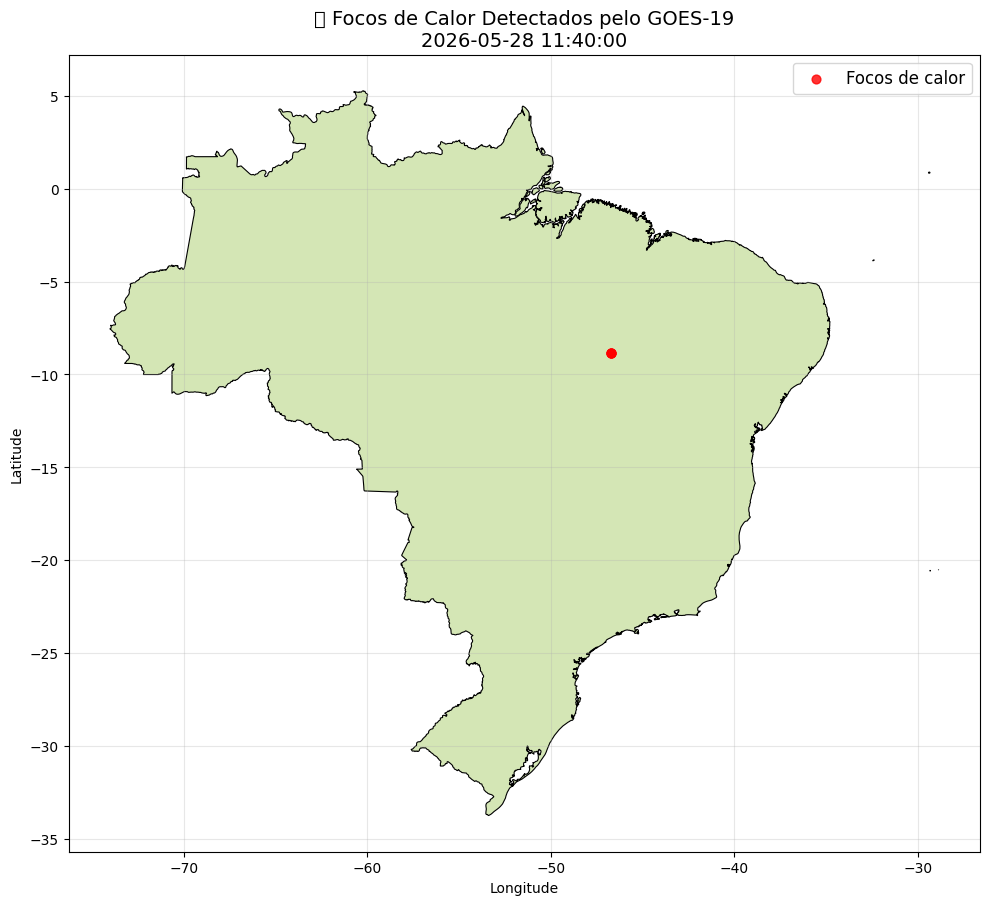

✅ Mapa salvo!


In [176]:
# Mapa melhorado com contorno do Brasil
import geopandas as gpd
from shapely.geometry import Point

# Baixando shapefile do Brasil direto da internet
url_brasil = "https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson"
mundo = gpd.read_file(url_brasil)
brasil = mundo[mundo["name"] == "Brazil"]

# Convertendo focos para GeoDataFrame
geometry = [Point(xy) for xy in zip(df_focos["lon"], df_focos["lat"])]
gdf_focos = gpd.GeoDataFrame(df_focos, geometry=geometry, crs="EPSG:4326")

# Plotando
fig, ax = plt.subplots(figsize=(10, 12))
brasil.plot(ax=ax, color="#d4e6b5", edgecolor="black", linewidth=0.8)
gdf_focos.plot(ax=ax, color="red", markersize=40, alpha=0.8, label="Focos de calor")

ax.set_title(f"🔥 Focos de Calor Detectados pelo GOES-19\n{df_focos['data'].max()}", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/processed/mapa_focos_calor.png", dpi=150)
plt.show()
print("✅ Mapa salvo!")





Total de focos: 4
Focos dentro do Brasil: 4


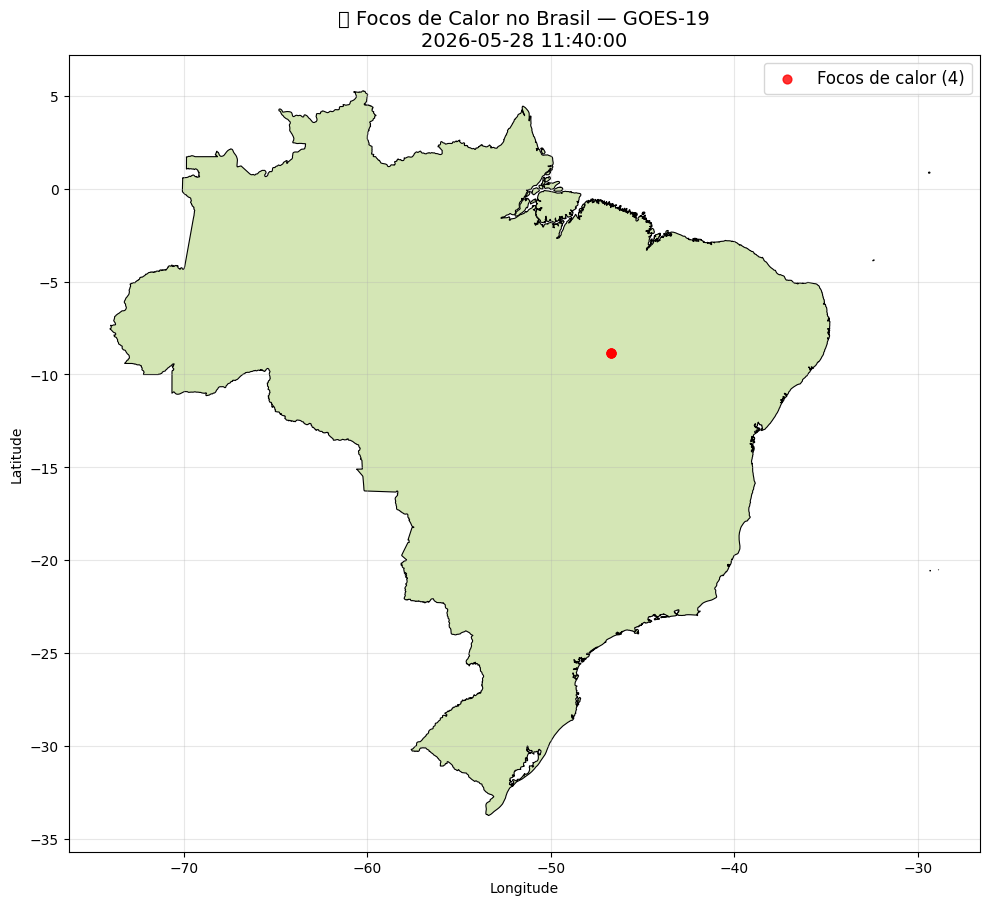

✅ Mapa salvo!


In [177]:
# Filtrando apenas focos dentro do Brasil
from shapely.ops import unary_union

brasil_shape = unary_union(brasil.geometry)
gdf_focos["dentro_brasil"] = gdf_focos.geometry.within(brasil_shape)
df_focos_brasil = gdf_focos[gdf_focos["dentro_brasil"]]

print(f"Total de focos: {len(gdf_focos)}")
print(f"Focos dentro do Brasil: {len(df_focos_brasil)}")

# Plotando apenas focos do Brasil
fig, ax = plt.subplots(figsize=(10, 12))
brasil.plot(ax=ax, color="#d4e6b5", edgecolor="black", linewidth=0.8)
df_focos_brasil.plot(ax=ax, color="red", markersize=40, alpha=0.8, label=f"Focos de calor ({len(df_focos_brasil)})")

ax.set_title(f"🔥 Focos de Calor no Brasil — GOES-19\n{df_focos['data'].max()}", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/processed/mapa_focos_calor.png", dpi=150)
plt.show()
print("✅ Mapa salvo!")

In [178]:
# Testando URLs alternativas da ANEEL
urls = [
    "https://dadosabertos.aneel.gov.br/dataset/ramais-de-transmissao",
    "https://sigel.aneel.gov.br/arcgis/rest/services/SIGEL/ExportacaoDados/MapServer",
    "https://sigel.aneel.gov.br/arcgis/rest/services",
]

for url in urls:
    try:
        r = requests.get(url, verify=False, timeout=10)
        print(f"Status {r.status_code}: {url}")
    except Exception as e:
        print(f"❌ Erro: {url}")

Status 404: https://dadosabertos.aneel.gov.br/dataset/ramais-de-transmissao
Status 200: https://sigel.aneel.gov.br/arcgis/rest/services/SIGEL/ExportacaoDados/MapServer
Status 200: https://sigel.aneel.gov.br/arcgis/rest/services


In [179]:
# Listando todos os serviços disponíveis no SIGEL
url_services = "https://sigel.aneel.gov.br/arcgis/rest/services?f=json"

r = requests.get(url_services, verify=False, timeout=15)
dados = json.loads(r.text)

print("Serviços disponíveis:")
for service in dados.get("services", []):
    print(f"  - {service['name']} ({service['type']})")

Serviços disponíveis:
  - CartasTopograficas (MapServer)
  - check_data (MapServer)
  - Features_DEEP_UFV2 (FeatureServer)
  - Features_DEEP_UFV2 (MapServer)
  - GEO_SMA_SDE_AREA_ATUACAO_DIST_LIM_MUNICIPAL_2018 (MapServer)
  - Geracao_Distribuida_SIGEL (FeatureServer)
  - Geracao_Distribuida_SIGEL (MapServer)
  - Geração_Distribuída_MIL1 (MapServer)
  - Leilões_ANEEL_MIL1 (MapServer)
  - Mapa_base_validador_UFV_MIL1 (MapServer)
  - Mapa_base_validador_UFV_MIL2 (MapServer)
  - SampleWorldCities (MapServer)
  - Script_Export_CSV_Imagem (GPServer)
  - UFV_time (FeatureServer)
  - UFV_time (MapServer)
  - Validador_UFV (FeatureServer)
  - Validador_UFV (MapServer)
  - Web_Layer_Dash_UFV (FeatureServer)
  - Web_Layer_Dash_UFV (MapServer)
  - Web_Layer_UFV_Areas_Especiais (FeatureServer)
  - Web_Layer_UFV_Areas_Especiais (MapServer)
  - Web_Layer_UFV_Bases_Validador_UFV (FeatureServer)
  - Web_Layer_UFV_Bases_Validador_UFV (MapServer)
  - Web_Layer_UFV_Outras_Bases (FeatureServer)
  - Web_La

In [180]:
# Explorando camadas de Usinas Fotovoltaicas (UFV)
url_ufv = "https://sigel.aneel.gov.br/arcgis/rest/services/Web_Layer_UFV_Outras_Bases/MapServer?f=json"

r = requests.get(url_ufv, verify=False, timeout=15)
dados = json.loads(r.text)

print("Camadas UFV disponíveis:")
for layer in dados.get("layers", []):
    print(f"  ID {layer['id']}: {layer['name']}")

Camadas UFV disponíveis:
  ID 27: Linhas de Transmissão - EOL Aprovada
  ID 24: Área de Desenvolvimento de Subestações
  ID 25: Declaração de Utilidade Pública


In [181]:
# Carregando via json.loads
import json
from io import StringIO

dados_lt = json.loads(r_lt.text)
print(f"Tipo: {type(dados_lt)}")
print(f"Chaves: {list(dados_lt.keys())}")
print(f"Total features: {len(dados_lt.get('features', []))}")

# Convertendo para GeoDataFrame
gdf_lt = gpd.GeoDataFrame.from_features(dados_lt["features"])
print(f"✅ {len(gdf_lt)} linhas de transmissão carregadas!")
print(f"Colunas: {list(gdf_lt.columns)}")

Tipo: <class 'dict'>
Chaves: ['type', 'features']
Total features: 437
✅ 437 linhas de transmissão carregadas!
Colunas: ['geometry', 'OBJECTID', 'NOME_RESP', 'COMPART', 'TENSAO_KV', 'EOL_VERSAO_ID', 'DATA_ATUALIZACAO', 'ID_LT', 'VERSAO', 'OPERACAO_COMERCIAL', 'USO', 'ORIGEM', 'SHAPE.STLength()']


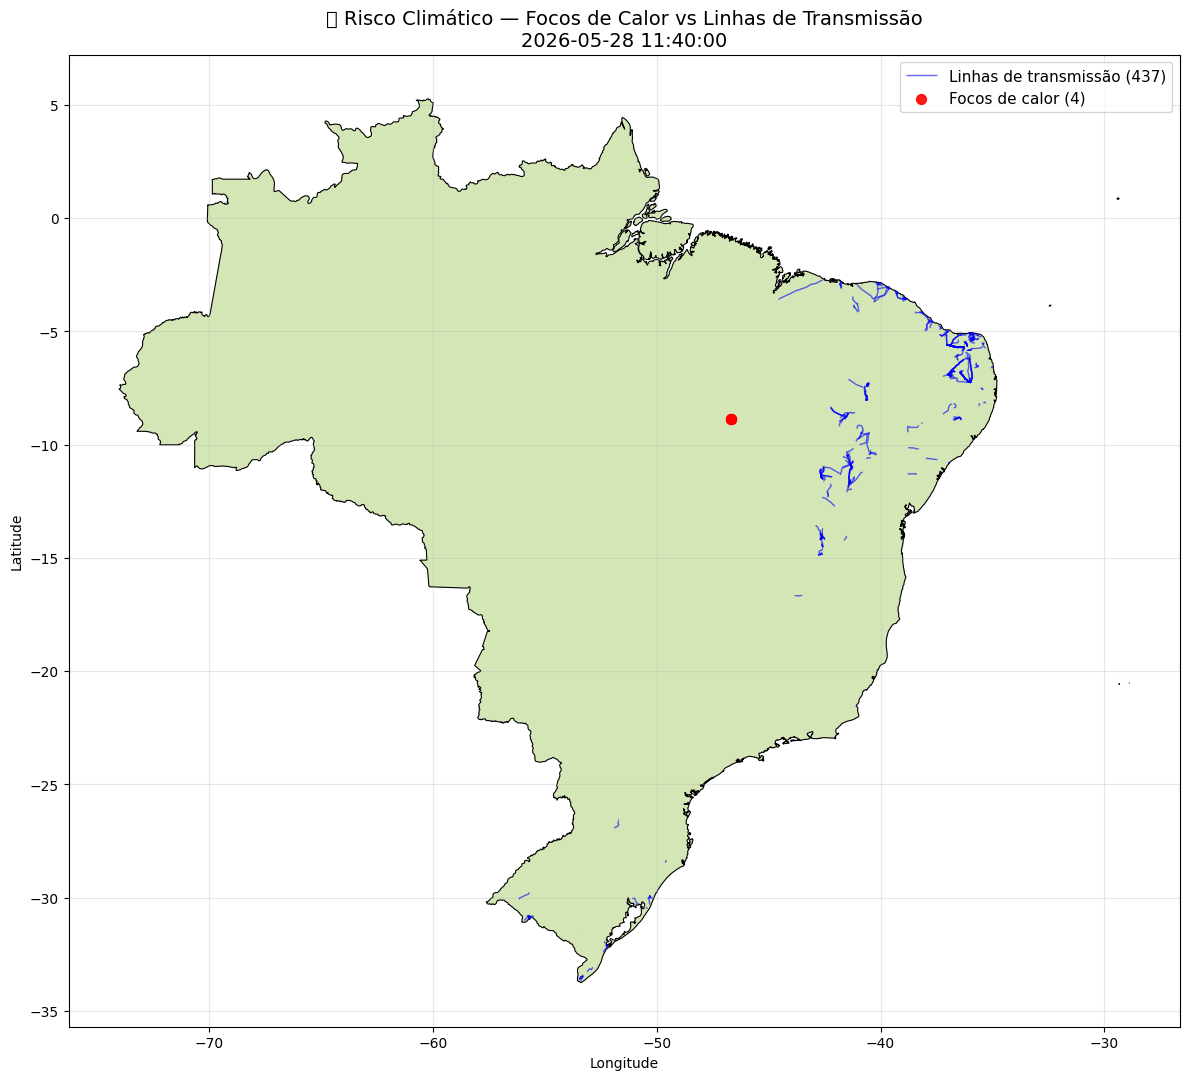

✅ Mapa de risco salvo!


In [182]:
# Mapa combinado — Focos de calor + Linhas de Transmissão
fig, ax = plt.subplots(figsize=(12, 14))

# Brasil
brasil.plot(ax=ax, color="#d4e6b5", edgecolor="black", linewidth=0.8)

# Linhas de transmissão
gdf_lt.set_crs("EPSG:4326", inplace=True, allow_override=True)
gdf_lt.plot(ax=ax, color="blue", linewidth=1, alpha=0.6, label=f"Linhas de transmissão (437)")

# Focos de calor
df_focos_brasil.plot(ax=ax, color="red", markersize=50, alpha=0.9, label=f"Focos de calor ({len(df_focos_brasil)})")

ax.set_title(f"🔥 Risco Climático — Focos de Calor vs Linhas de Transmissão\n{df_focos['data'].max()}", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/processed/mapa_risco_transmissao.png", dpi=150)
plt.show()
print("✅ Mapa de risco salvo!")

In [183]:
# Descobrindo o total de registros disponíveis
url_count = "https://sigel.aneel.gov.br/arcgis/rest/services/Web_Layer_UFV_Outras_Bases/MapServer/27/query?where=1%3D1&returnCountOnly=true&f=json"

r_count = requests.get(url_count, verify=False, timeout=15)
total = json.loads(r_count.text)
print(f"Total de registros disponíveis: {total}")

Total de registros disponíveis: {'count': 437}


In [184]:
# Baixando camadas uma por vez com tratamento de erro
base_url = "https://sigel.aneel.gov.br/arcgis/rest/services/Web_Layer_UFV_Outras_Bases/MapServer"

camadas = {
    27: "Linhas de Transmissão",
    24: "Subestações",
    25: "Utilidade Pública"
}

gdfs = {}
for id_camada, nome in camadas.items():
    try:
        url = f"{base_url}/{id_camada}/query?where=1%3D1&outFields=*&f=geojson"
        r = requests.get(url, verify=False, timeout=60)
        dados = json.loads(r.text)
        features = dados.get("features", [])
        if features:
            gdf = gpd.GeoDataFrame.from_features(features)
            gdf.set_crs("EPSG:4326", inplace=True, allow_override=True)
            gdfs[nome] = gdf
            print(f"✅ {nome}: {len(gdf)} registros")
        else:
            print(f"⬜ {nome}: sem dados")
    except Exception as e:
        print(f"❌ {nome}: {e}")

✅ Linhas de Transmissão: 437 registros
✅ Subestações: 718 registros
❌ Utilidade Pública: ("Connection broken: FileNotFoundError(2, 'No such file or directory')", FileNotFoundError(2, 'No such file or directory'))


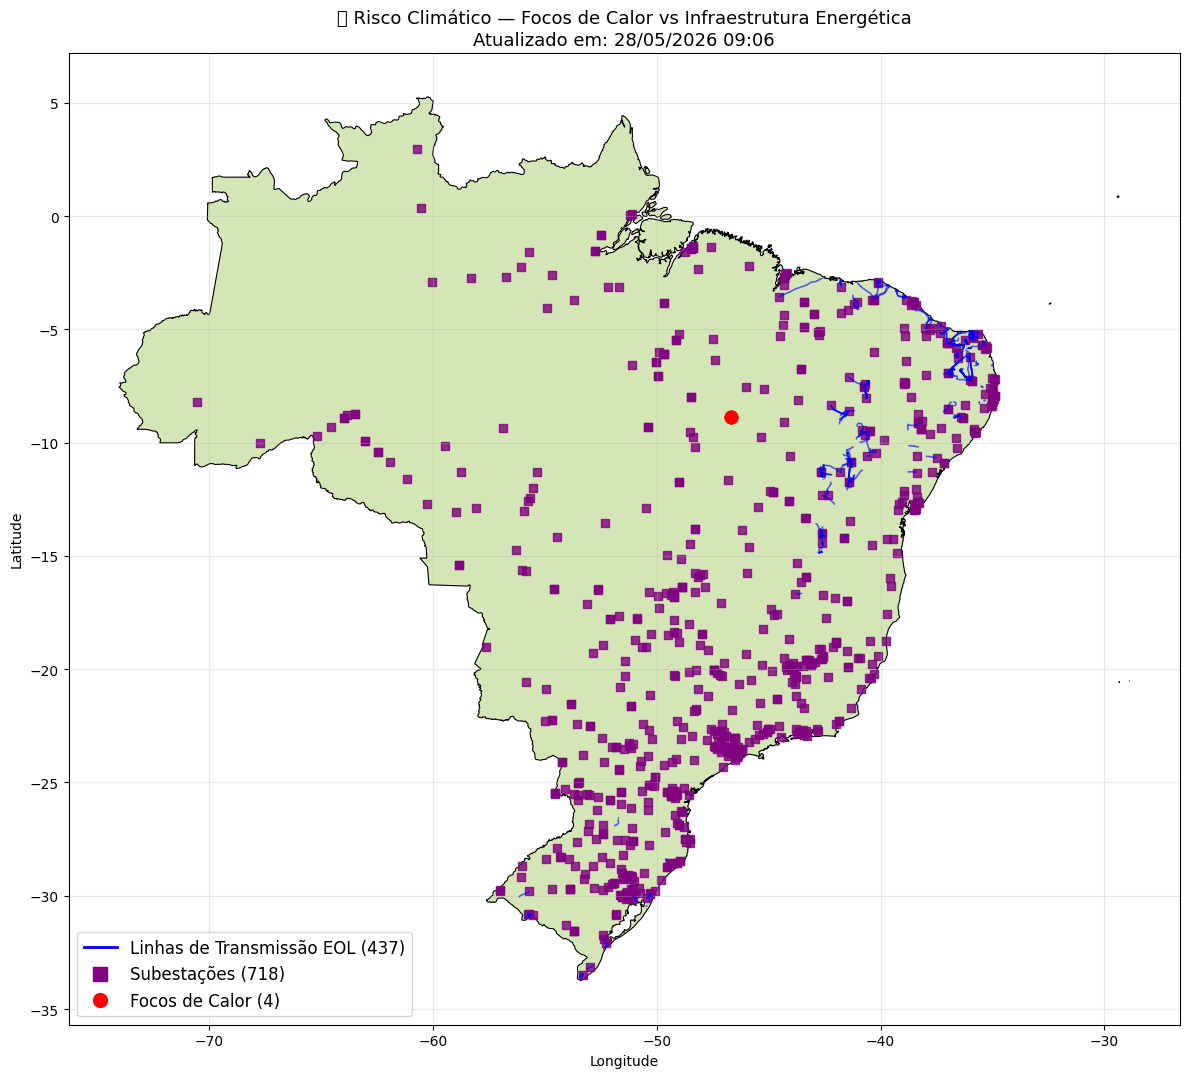

✅ Mapa completo salvo!


In [185]:
# Mapa completo — Focos de Calor + Linhas de Transmissão + Subestações
import matplotlib.lines as mlines
from datetime import datetime

# Calculando centroides das subestações
gdfs["Subestações"]["centroide"] = gdfs["Subestações"].geometry.centroid
gdf_sub_centroides = gpd.GeoDataFrame(gdfs["Subestações"], geometry="centroide", crs="EPSG:4326")

# Hora atual
agora = datetime.now().strftime("%d/%m/%Y %H:%M")

fig, ax = plt.subplots(figsize=(12, 14))

# Brasil
brasil.plot(ax=ax, color="#d4e6b5", edgecolor="black", linewidth=0.8)

# Linhas de transmissão
gdfs["Linhas de Transmissão"].plot(ax=ax, color="blue", linewidth=1.2, alpha=0.6)

# Subestações como centroides
gdf_sub_centroides.plot(ax=ax, color="purple", markersize=30, alpha=0.8, marker="s")

# Focos de calor
df_focos_brasil.plot(ax=ax, color="red", markersize=80, alpha=0.9, marker="o")

# Legenda manual
legenda = [
    mlines.Line2D([], [], color="blue", linewidth=2, label=f"Linhas de Transmissão EOL ({len(gdfs['Linhas de Transmissão'])})"),
    mlines.Line2D([], [], color="purple", marker="s", markersize=10, linestyle="None", label=f"Subestações ({len(gdf_sub_centroides)})"),
    mlines.Line2D([], [], color="red", marker="o", markersize=10, linestyle="None", label=f"Focos de Calor ({len(df_focos_brasil)})"),
]

ax.legend(handles=legenda, fontsize=12, loc="lower left")
ax.set_title(f"🔥 Risco Climático — Focos de Calor vs Infraestrutura Energética\nAtualizado em: {agora}", fontsize=13)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/processed/mapa_risco_infraestrutura.png", dpi=150)
plt.show()
print("✅ Mapa completo salvo!")

In [186]:
kmz_path = "../data/raw/[EPE] Linhas de Transmissão.kmz"

# Tentando abrir como zip
try:
    with zipfile.ZipFile(kmz_path, 'r') as kmz:
        print(f"Arquivos dentro do KMZ: {kmz.namelist()}")
        for arquivo in kmz.namelist():
            if arquivo.endswith('.kml'):
                kmz.extract(arquivo, "../data/raw/")
                print(f"✅ Extraído: {arquivo}")
except Exception as e:
    print(f"Erro: {e}")

Arquivos dentro do KMZ: ['doc.kml']
✅ Extraído: doc.kml


In [187]:
# Lendo KML direto
kml_path = "../data/raw/doc.kml"

try:
    gdf_lt_epe = gpd.read_file(kml_path)
    print(f"✅ {len(gdf_lt_epe)} registros carregados!")
    print(f"Colunas: {list(gdf_lt_epe.columns)}")
    print(gdf_lt_epe.head(3))
except Exception as e:
    print(f"Erro: {e}")

✅ 2316 registros carregados!
Colunas: ['id', 'Name', 'description', 'timestamp', 'begin', 'end', 'altitudeMode', 'tessellate', 'extrude', 'visibility', 'drawOrder', 'icon', 'Nome', 'Concess__o', 'Tens__o__kV_', 'Extens__o__km_', 'Ano_de_Opera____o___Planejamento', 'Status', 'geometry']
   id                                      Name  \
0  47     LT 230 kV Paranatinga  - Canarana, C1   
1  58    LT 230 kV Maçambará - Santo Ângelo, C2   
2  69  LT 500 kV Itabirito 2 - Vespasiano 2, C1   

                                         description timestamp begin end  \
0  <table>\n<tr style="background-color:#DDDDFF;"...       NaT   NaT NaT   
1  <table>\n<tr style="background-color:#DDDDFF;"...       NaT   NaT NaT   
2  <table>\n<tr style="background-color:#DDDDFF;"...       NaT   NaT NaT   

  altitudeMode  tessellate  extrude  visibility  drawOrder  icon  \
0         None          -1        0          -1        NaN  None   
1         None          -1        0          -1        NaN  None   

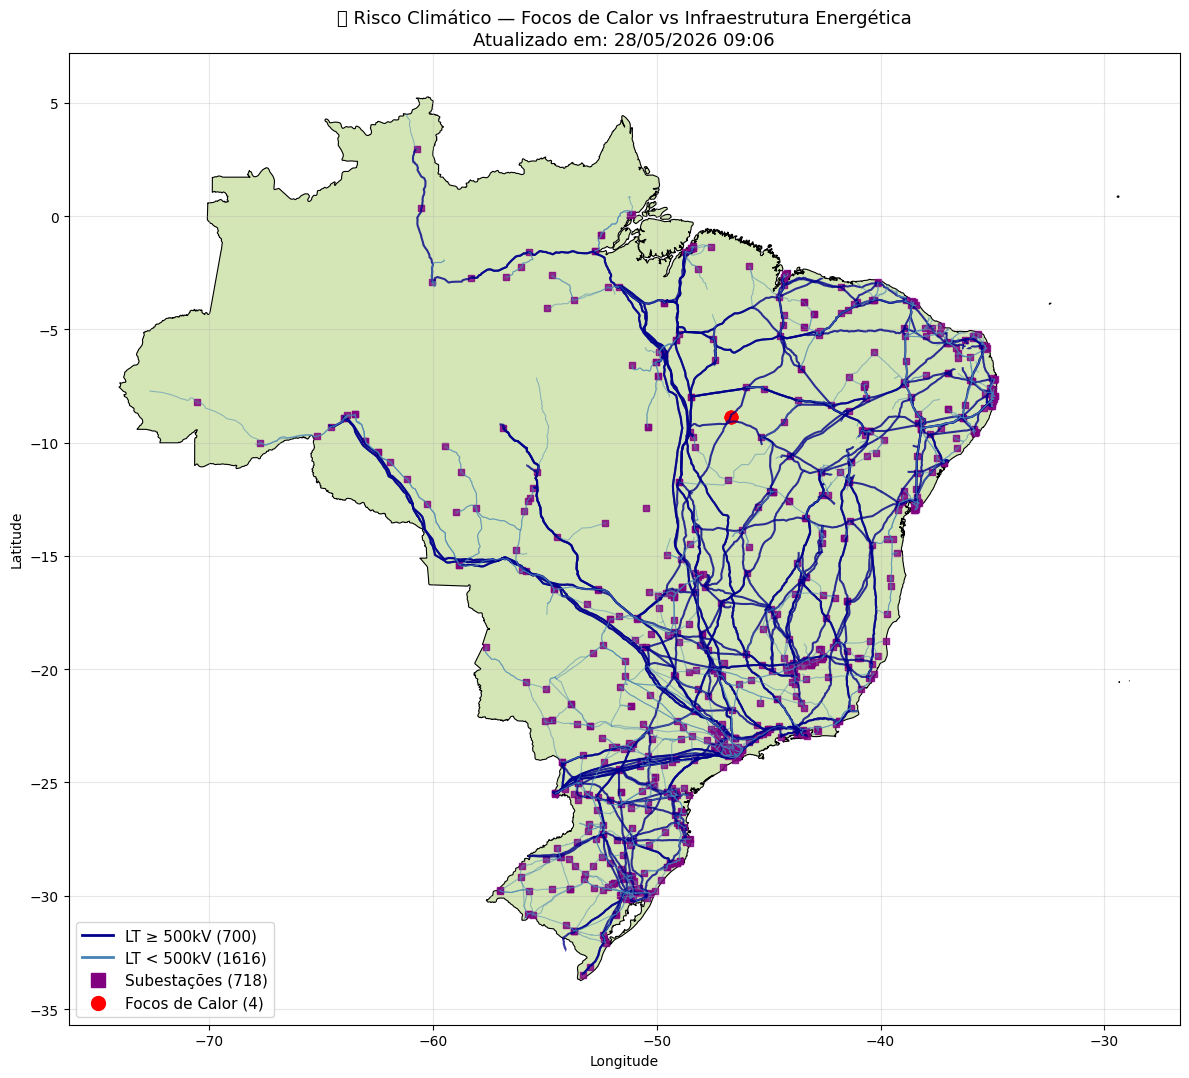

✅ Mapa completo salvo!


In [188]:
# Convertendo tensão para número
gdf_lt_epe["Tens__o__kV_"] = pd.to_numeric(gdf_lt_epe["Tens__o__kV_"], errors="coerce")

# Mapa completo com linhas de transmissão reais da EPE
import matplotlib.lines as mlines
from datetime import datetime

# Calculando centroides das subestações
gdfs["Subestações"]["centroide"] = gdfs["Subestações"].geometry.centroid
gdf_sub_centroides = gpd.GeoDataFrame(gdfs["Subestações"], geometry="centroide", crs="EPSG:4326")

agora = datetime.now().strftime("%d/%m/%Y %H:%M")

fig, ax = plt.subplots(figsize=(12, 14))

# Brasil
brasil.plot(ax=ax, color="#d4e6b5", edgecolor="black", linewidth=0.8)

# Linhas por tensão
lt_alta = gdf_lt_epe[gdf_lt_epe["Tens__o__kV_"] >= 500]
lt_media = gdf_lt_epe[gdf_lt_epe["Tens__o__kV_"] < 500]

lt_alta.plot(ax=ax, color="darkblue", linewidth=1.5, alpha=0.8)
lt_media.plot(ax=ax, color="steelblue", linewidth=0.8, alpha=0.5)

# Subestações
gdf_sub_centroides.plot(ax=ax, color="purple", markersize=25, alpha=0.8, marker="s")

# Focos de calor
df_focos_brasil.plot(ax=ax, color="red", markersize=80, alpha=0.9, marker="o")

# Legenda
legenda = [
    mlines.Line2D([], [], color="darkblue", linewidth=2, label=f"LT ≥ 500kV ({len(lt_alta)})"),
    mlines.Line2D([], [], color="steelblue", linewidth=2, label=f"LT < 500kV ({len(lt_media)})"),
    mlines.Line2D([], [], color="purple", marker="s", markersize=10, linestyle="None", label=f"Subestações ({len(gdf_sub_centroides)})"),
    mlines.Line2D([], [], color="red", marker="o", markersize=10, linestyle="None", label=f"Focos de Calor ({len(df_focos_brasil)})"),
]

ax.legend(handles=legenda, fontsize=11, loc="lower left")
ax.set_title(f"🔥 Risco Climático — Focos de Calor vs Infraestrutura Energética\nAtualizado em: {agora}", fontsize=13)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/processed/mapa_risco_infraestrutura.png", dpi=150)
plt.show()
print("✅ Mapa completo salvo!")

Distribuição por tensão:
  ≥ 750 kV: 14 linhas
  500 kV:   686 linhas
  345 kV:   265 linhas
  230 kV:   1350 linhas
  < 230 kV: 1 linhas


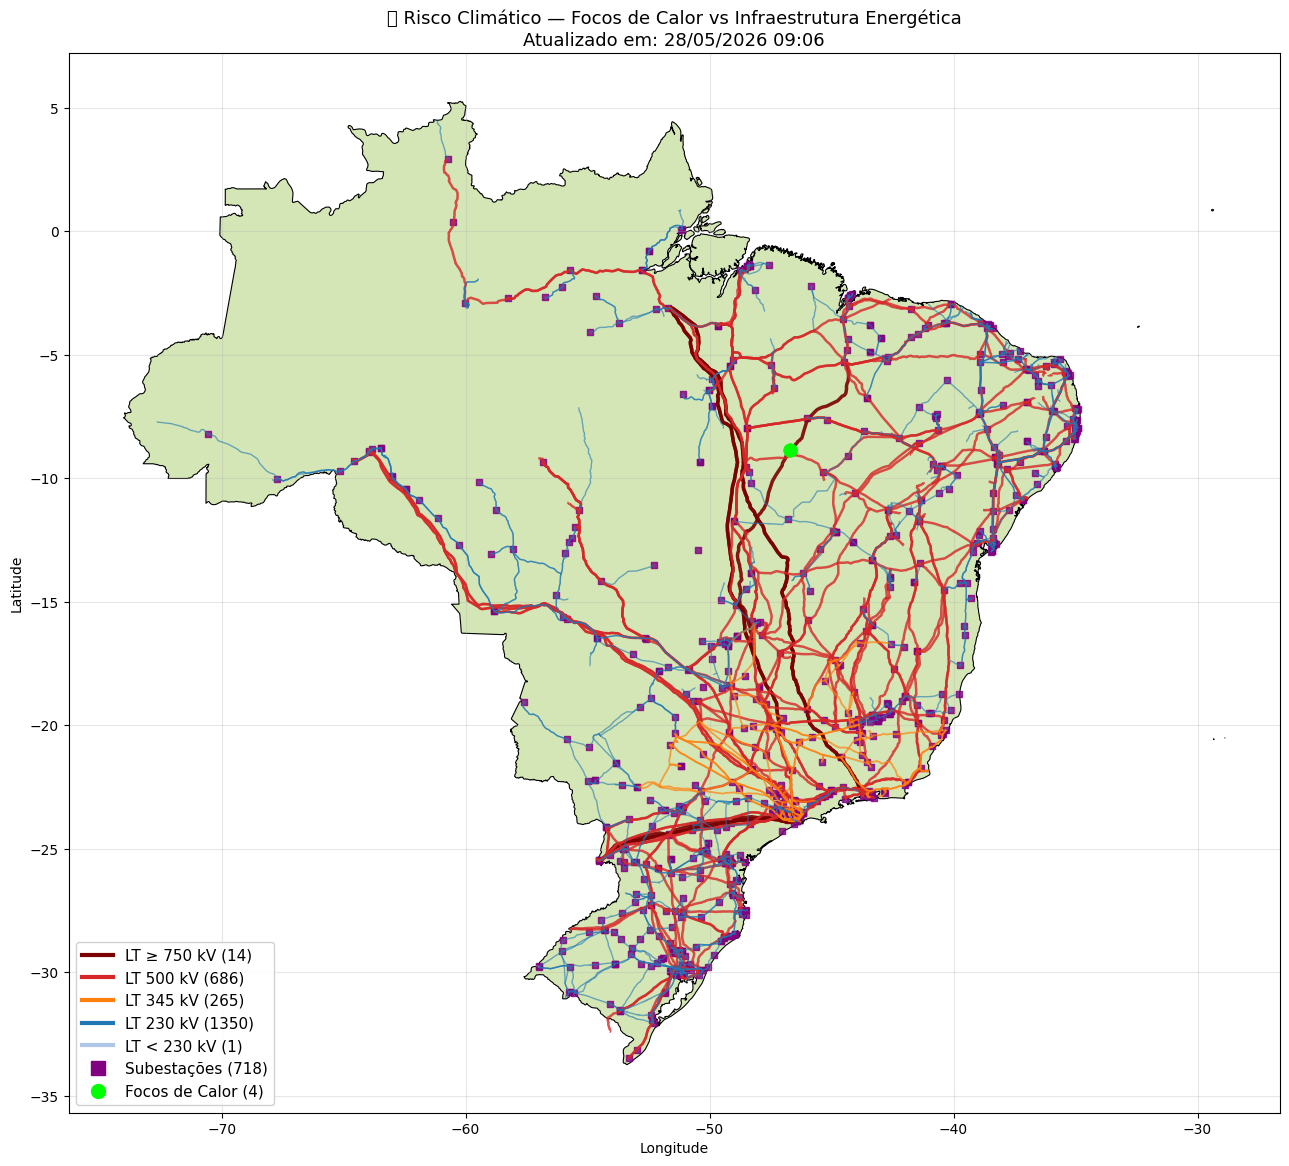

✅ Mapa completo salvo!


In [189]:
# Convertendo tensão para número
gdf_lt_epe["Tens__o__kV_"] = pd.to_numeric(gdf_lt_epe["Tens__o__kV_"], errors="coerce")

# Separando por faixa de tensão
lt_750 = gdf_lt_epe[gdf_lt_epe["Tens__o__kV_"] >= 750]
lt_500 = gdf_lt_epe[(gdf_lt_epe["Tens__o__kV_"] >= 500) & (gdf_lt_epe["Tens__o__kV_"] < 750)]
lt_345 = gdf_lt_epe[(gdf_lt_epe["Tens__o__kV_"] >= 345) & (gdf_lt_epe["Tens__o__kV_"] < 500)]
lt_230 = gdf_lt_epe[(gdf_lt_epe["Tens__o__kV_"] >= 230) & (gdf_lt_epe["Tens__o__kV_"] < 345)]
lt_baixa = gdf_lt_epe[gdf_lt_epe["Tens__o__kV_"] < 230]

print("Distribuição por tensão:")
print(f"  ≥ 750 kV: {len(lt_750)} linhas")
print(f"  500 kV:   {len(lt_500)} linhas")
print(f"  345 kV:   {len(lt_345)} linhas")
print(f"  230 kV:   {len(lt_230)} linhas")
print(f"  < 230 kV: {len(lt_baixa)} linhas")

# Mapa completo
import matplotlib.lines as mlines
from datetime import datetime

gdfs["Subestações"]["centroide"] = gdfs["Subestações"].geometry.centroid
gdf_sub_centroides = gpd.GeoDataFrame(gdfs["Subestações"], geometry="centroide", crs="EPSG:4326")

agora = datetime.now().strftime("%d/%m/%Y %H:%M")

fig, ax = plt.subplots(figsize=(13, 15))

# Brasil
brasil.plot(ax=ax, color="#d4e6b5", edgecolor="black", linewidth=0.8)

# Linhas por tensão com cores distintas
if len(lt_750) > 0:
    lt_750.plot(ax=ax, color="#7b0000", linewidth=2.5, alpha=0.9)
if len(lt_500) > 0:
    lt_500.plot(ax=ax, color="#d62728", linewidth=1.8, alpha=0.8)
if len(lt_345) > 0:
    lt_345.plot(ax=ax, color="#ff7f0e", linewidth=1.3, alpha=0.7)
if len(lt_230) > 0:
    lt_230.plot(ax=ax, color="#1f77b4", linewidth=1.0, alpha=0.6)
if len(lt_baixa) > 0:
    lt_baixa.plot(ax=ax, color="#aec7e8", linewidth=0.7, alpha=0.5)

# Subestações
gdf_sub_centroides.plot(ax=ax, color="purple", markersize=25, alpha=0.8, marker="s")

# Focos de calor
df_focos_brasil.plot(ax=ax, color="lime", markersize=80, alpha=0.9, marker="o", zorder=5)

# Legenda
legenda = [
    mlines.Line2D([], [], color="#7b0000", linewidth=3, label=f"LT ≥ 750 kV ({len(lt_750)})"),
    mlines.Line2D([], [], color="#d62728", linewidth=3, label=f"LT 500 kV ({len(lt_500)})"),
    mlines.Line2D([], [], color="#ff7f0e", linewidth=3, label=f"LT 345 kV ({len(lt_345)})"),
    mlines.Line2D([], [], color="#1f77b4", linewidth=3, label=f"LT 230 kV ({len(lt_230)})"),
    mlines.Line2D([], [], color="#aec7e8", linewidth=3, label=f"LT < 230 kV ({len(lt_baixa)})"),
    mlines.Line2D([], [], color="purple", marker="s", markersize=10, linestyle="None", label=f"Subestações ({len(gdf_sub_centroides)})"),
    mlines.Line2D([], [], color="lime", marker="o", markersize=10, linestyle="None", label=f"Focos de Calor ({len(df_focos_brasil)})"),
]

ax.legend(handles=legenda, fontsize=11, loc="lower left", framealpha=0.9)
ax.set_title(f"🔥 Risco Climático — Focos de Calor vs Infraestrutura Energética\nAtualizado em: {agora}", fontsize=13)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/processed/mapa_risco_infraestrutura.png", dpi=150)
plt.show()
print("✅ Mapa completo salvo!")

Calculando distâncias e identificando infraestrutura mais próxima...
Calculando linhas... (pode demorar ~1 min)
Calculando subestações...

🚨 SISTEMA DE ALERTAS SATENERGY — 28/05/2026 09:06

Distribuição de risco:
risco
🔴 CRÍTICO    4
Name: count, dtype: int64

Top 15 focos mais críticos:
  Lat   Lon  Dist LT (km)                    Linha Ameaçada  Tensão (kV)  Dist SUB (km)  Subestação     Risco
-8.85 -46.7          0.32 LT 800 kV Graça Aranha – Silvânia        800.0         161.71       603.0 🔴 CRÍTICO
-8.85 -46.7          0.32 LT 800 kV Graça Aranha – Silvânia        800.0         161.71       603.0 🔴 CRÍTICO
-8.85 -46.7          0.32 LT 800 kV Graça Aranha – Silvânia        800.0         161.71       603.0 🔴 CRÍTICO
-8.85 -46.7          0.32 LT 800 kV Graça Aranha – Silvânia        800.0         161.71       603.0 🔴 CRÍTICO

✅ Alertas salvos em data/processed/alertas_risco.csv


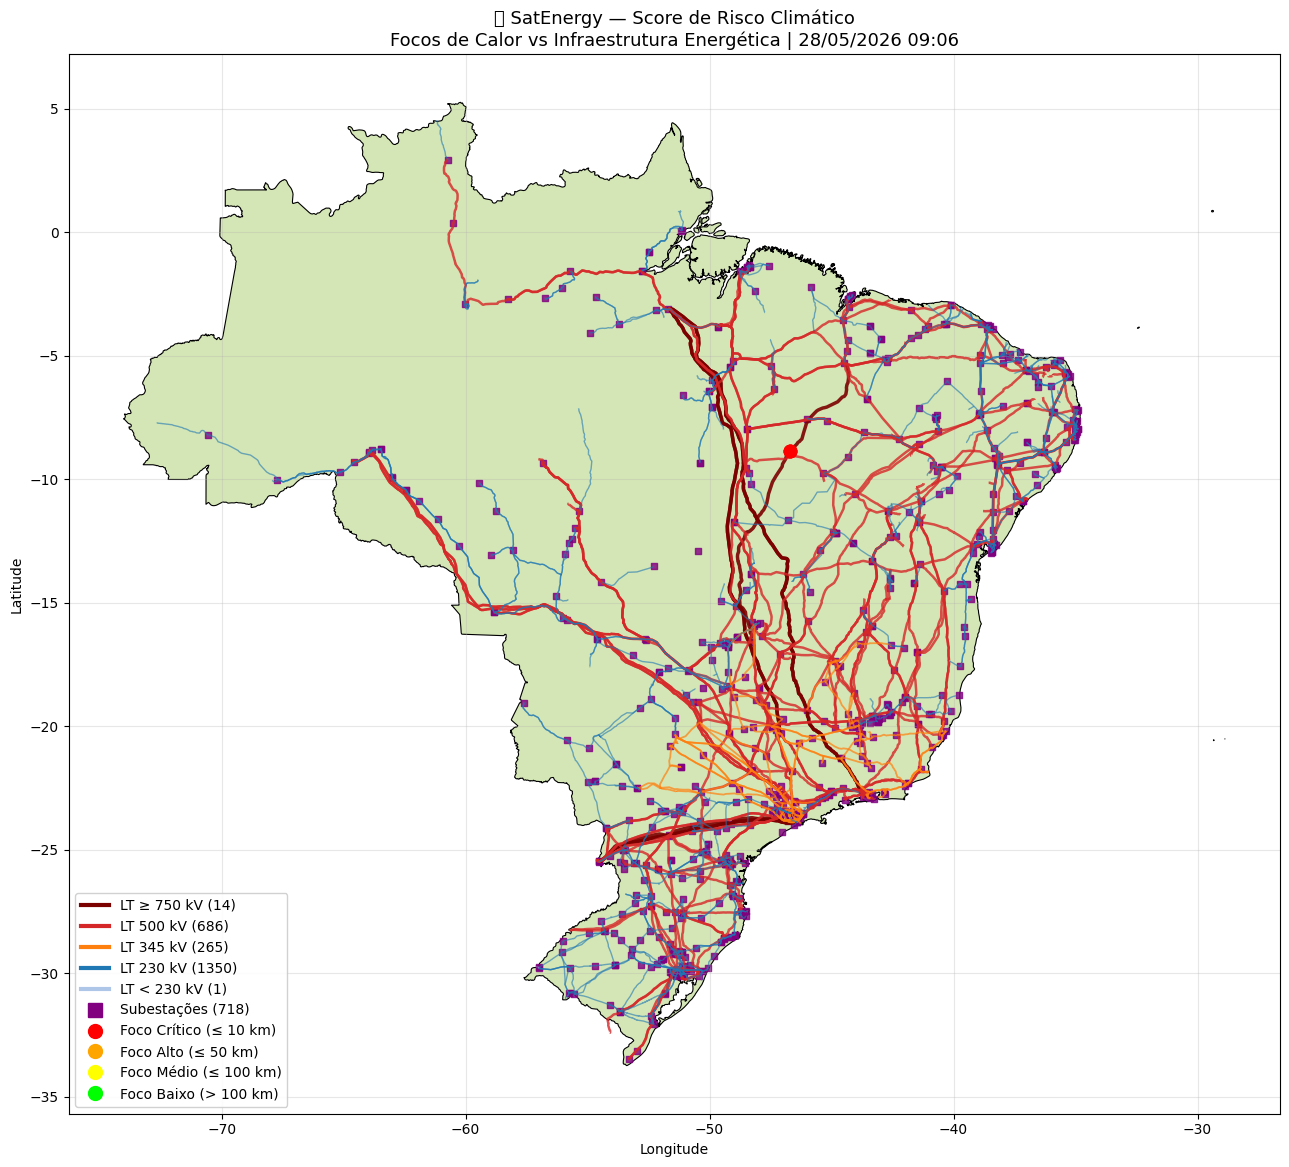

✅ Mapa de score de risco salvo!


In [190]:
# Sistema de Alertas SatEnergy
from shapely.ops import nearest_points
import numpy as np
from datetime import datetime

# Reprojetando para sistema métrico
gdf_focos_proj = df_focos_brasil.to_crs("EPSG:31983")
gdf_lt_proj = gdf_lt_epe.to_crs("EPSG:31983")
gdf_sub_proj = gdf_sub_centroides.to_crs("EPSG:31983")

print("Calculando distâncias e identificando infraestrutura mais próxima...")

# Para cada foco, encontra a linha mais próxima
def linha_mais_proxima(ponto):
    distancias = gdf_lt_proj.geometry.distance(ponto)
    idx = distancias.idxmin()
    return pd.Series({
        "dist_linha_km": distancias[idx] / 1000,
        "linha_nome": gdf_lt_epe.loc[idx, "Nome"],
        "linha_tensao_kv": gdf_lt_epe.loc[idx, "Tens__o__kV_"],
    })

# Para cada foco, encontra a subestação mais próxima
def sub_mais_proxima(ponto):
    distancias = gdf_sub_proj.geometry.distance(ponto)
    idx = distancias.idxmin()
    sub = gdfs["Subestações"]
    nome_col = "nom_pontoconexao" if "nom_pontoconexao" in sub.columns else sub.columns[1]
    return pd.Series({
        "dist_sub_km": distancias[idx] / 1000,
        "sub_nome": sub.loc[idx, nome_col],
    })

print("Calculando linhas... (pode demorar ~1 min)")
df_linhas = gdf_focos_proj.geometry.apply(linha_mais_proxima)

print("Calculando subestações...")
df_subs = gdf_focos_proj.geometry.apply(sub_mais_proxima)

# Juntando tudo
gdf_focos_proj = pd.concat([gdf_focos_proj.reset_index(drop=True), 
                             df_linhas.reset_index(drop=True), 
                             df_subs.reset_index(drop=True)], axis=1)
gdf_focos_proj["dist_min_km"] = gdf_focos_proj[["dist_linha_km", "dist_sub_km"]].min(axis=1)

# Classificando risco
def classificar_risco(dist):
    if dist <= 10:
        return "🔴 CRÍTICO"
    elif dist <= 50:
        return "🟠 ALTO"
    elif dist <= 100:
        return "🟡 MÉDIO"
    else:
        return "🟢 BAIXO"

gdf_focos_proj["risco"] = gdf_focos_proj["dist_min_km"].apply(classificar_risco)

# Tabela de alertas
agora = datetime.now().strftime("%d/%m/%Y %H:%M")
print("\n" + "=" * 80)
print(f"🚨 SISTEMA DE ALERTAS SATENERGY — {agora}")
print("=" * 80)

print(f"\nDistribuição de risco:")
print(gdf_focos_proj["risco"].value_counts())

print(f"\nTop 15 focos mais críticos:")
cols = ["lat", "lon", "dist_linha_km", "linha_nome", "linha_tensao_kv", "dist_sub_km", "sub_nome", "risco"]
df_alertas = gdf_focos_proj[cols].copy()
df_alertas = df_alertas.sort_values("dist_linha_km").head(15).round(2)
df_alertas.columns = ["Lat", "Lon", "Dist LT (km)", "Linha Ameaçada", "Tensão (kV)", "Dist SUB (km)", "Subestação", "Risco"]
print(df_alertas.to_string(index=False))

# Salvando alertas em CSV
df_alertas.to_csv("../data/processed/alertas_risco.csv", index=False)
print("\n✅ Alertas salvos em data/processed/alertas_risco.csv")

# Mapa com zonas de risco
import matplotlib.lines as mlines

fig, ax = plt.subplots(figsize=(13, 15))

# Brasil
brasil.plot(ax=ax, color="#d4e6b5", edgecolor="black", linewidth=0.8)

# Linhas de transmissão por tensão
lt_750 = gdf_lt_epe[gdf_lt_epe["Tens__o__kV_"] >= 750]
lt_500 = gdf_lt_epe[(gdf_lt_epe["Tens__o__kV_"] >= 500) & (gdf_lt_epe["Tens__o__kV_"] < 750)]
lt_345 = gdf_lt_epe[(gdf_lt_epe["Tens__o__kV_"] >= 345) & (gdf_lt_epe["Tens__o__kV_"] < 500)]
lt_230 = gdf_lt_epe[(gdf_lt_epe["Tens__o__kV_"] >= 230) & (gdf_lt_epe["Tens__o__kV_"] < 345)]
lt_baixa = gdf_lt_epe[gdf_lt_epe["Tens__o__kV_"] < 230]

if len(lt_750) > 0: lt_750.plot(ax=ax, color="#7b0000", linewidth=2.5, alpha=0.9)
if len(lt_500) > 0: lt_500.plot(ax=ax, color="#d62728", linewidth=1.8, alpha=0.8)
if len(lt_345) > 0: lt_345.plot(ax=ax, color="#ff7f0e", linewidth=1.3, alpha=0.7)
if len(lt_230) > 0: lt_230.plot(ax=ax, color="#1f77b4", linewidth=1.0, alpha=0.6)
if len(lt_baixa) > 0: lt_baixa.plot(ax=ax, color="#aec7e8", linewidth=0.7, alpha=0.5)

# Subestações
gdf_sub_centroides.plot(ax=ax, color="purple", markersize=25, alpha=0.8, marker="s")

# Focos coloridos por nível de risco
cores_risco = {
    "🔴 CRÍTICO": "red",
    "🟠 ALTO":    "orange",
    "🟡 MÉDIO":   "yellow",
    "🟢 BAIXO":   "lime",
}
for nivel, cor in cores_risco.items():
    subset = gdf_focos_proj[gdf_focos_proj["risco"] == nivel]
    if len(subset) > 0:
        gpd.GeoDataFrame(subset, geometry="geometry", crs="EPSG:31983").to_crs("EPSG:4326").plot(
            ax=ax, color=cor, markersize=80, alpha=0.9, marker="o", zorder=5
        )

# Legenda
legenda = [
    mlines.Line2D([], [], color="#7b0000", linewidth=3, label=f"LT ≥ 750 kV ({len(lt_750)})"),
    mlines.Line2D([], [], color="#d62728", linewidth=3, label=f"LT 500 kV ({len(lt_500)})"),
    mlines.Line2D([], [], color="#ff7f0e", linewidth=3, label=f"LT 345 kV ({len(lt_345)})"),
    mlines.Line2D([], [], color="#1f77b4", linewidth=3, label=f"LT 230 kV ({len(lt_230)})"),
    mlines.Line2D([], [], color="#aec7e8", linewidth=3, label=f"LT < 230 kV ({len(lt_baixa)})"),
    mlines.Line2D([], [], color="purple", marker="s", markersize=10, linestyle="None", label=f"Subestações ({len(gdf_sub_centroides)})"),
    mlines.Line2D([], [], color="red",    marker="o", markersize=10, linestyle="None", label="Foco Crítico (≤ 10 km)"),
    mlines.Line2D([], [], color="orange", marker="o", markersize=10, linestyle="None", label="Foco Alto (≤ 50 km)"),
    mlines.Line2D([], [], color="yellow", marker="o", markersize=10, linestyle="None", label="Foco Médio (≤ 100 km)"),
    mlines.Line2D([], [], color="lime",   marker="o", markersize=10, linestyle="None", label="Foco Baixo (> 100 km)"),
]

ax.legend(handles=legenda, fontsize=10, loc="lower left", framealpha=0.9)
ax.set_title(f"🚨 SatEnergy — Score de Risco Climático\nFocos de Calor vs Infraestrutura Energética | {agora}", fontsize=13)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/processed/mapa_score_risco.png", dpi=150)
plt.show()
print("✅ Mapa de score de risco salvo!")

🛰️ Buscando focos de calor do GOES-19...
✅ 87 focos brutos carregados
✅ 2 focos únicos dentro do Brasil
✅ Linhas de transmissão preparadas
✅ Reprojeção concluída
Calculando distâncias... (~1 min)

🚨 SISTEMA DE ALERTAS SATENERGY — 28/05/2026 09:08

Total de focos analisados: 2

Distribuição de risco:
risco
🟢 BAIXO      1
🔴 CRÍTICO    1
Name: count, dtype: int64

Top 15 focos mais críticos:
   Lat    Lon  Dist (km)                               Linha  Tensão (kV)   Sub Origem Sub Destino                             Concessionária     Risco
 -8.85 -46.70       0.32   LT 800 kV Graça Aranha – Silvânia        800.0 Graça Aranha    Silvânia                                        NaN 🔴 CRÍTICO
-11.63 -56.86     138.25 LT 500 kV UHE Colíder - Cláudia, C1        500.0  UHE Colíder     Cláudia Copel-gt - Copel Geração E Transmissão S.a   🟢 BAIXO

✅ Alertas salvos em data/processed/alertas_risco.csv


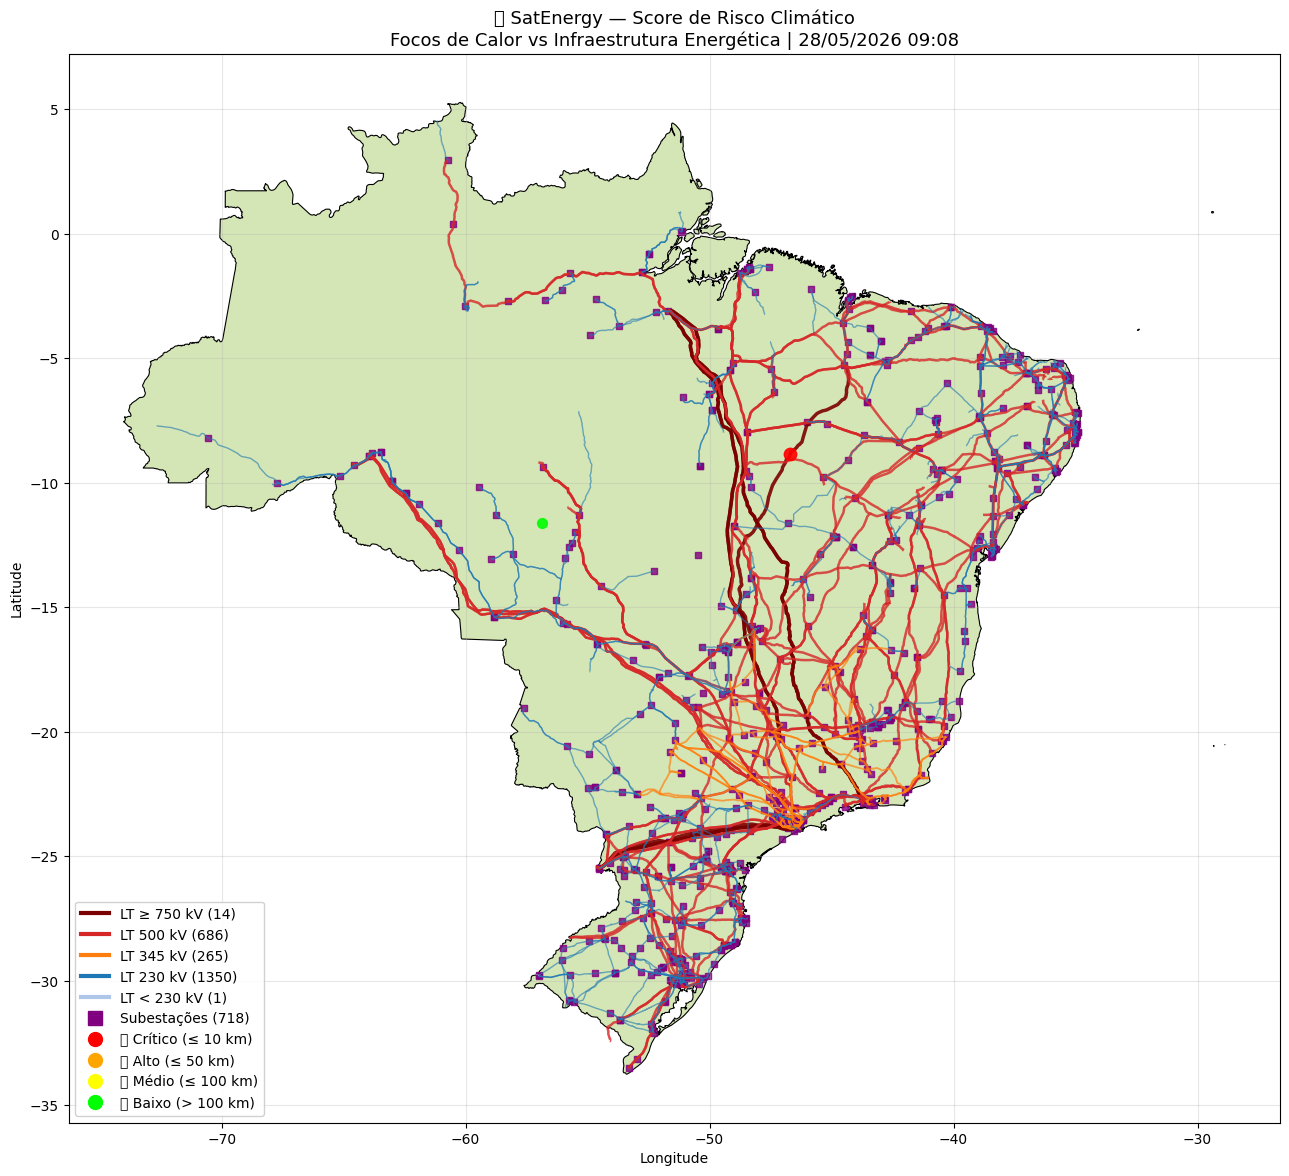

✅ Mapa de score de risco salvo!


In [193]:
# ============================================================
# SISTEMA DE ALERTAS SATENERGY — CÓDIGO COMPLETO E AUTÔNOMO
# ============================================================
from datetime import datetime
from io import StringIO
from shapely.geometry import Point
from shapely.ops import unary_union
import matplotlib.lines as mlines
import re

# PASSO 1 — Buscando focos das últimas 3 horas do INPE
print("🛰️ Buscando focos de calor do GOES-19...")
url_base = "https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/10min/"
r = requests.get(url_base, verify=False, timeout=15)
arquivos_csv = re.findall(r'href="(focos_[^"]+\.csv)"', r.text)

dfs = []
for arquivo in arquivos_csv[-18:]:
    url_arquivo = f"{url_base}{arquivo}"
    r_csv = requests.get(url_arquivo, verify=False, timeout=15)
    df_temp = pd.read_csv(StringIO(r_csv.text))
    if len(df_temp) > 0:
        dfs.append(df_temp)

df_focos = pd.concat(dfs, ignore_index=True)
print(f"✅ {len(df_focos)} focos brutos carregados")

# PASSO 2 — Filtrando focos dentro do Brasil e removendo duplicatas
geometry = [Point(xy) for xy in zip(df_focos["lon"], df_focos["lat"])]
gdf_todos = gpd.GeoDataFrame(df_focos, geometry=geometry, crs="EPSG:4326")
brasil_shape = unary_union(brasil.geometry)
gdf_todos["dentro_brasil"] = gdf_todos.geometry.within(brasil_shape)
df_focos_brasil = gdf_todos[gdf_todos["dentro_brasil"]].drop_duplicates(subset=["lat", "lon"]).reset_index(drop=True)
print(f"✅ {len(df_focos_brasil)} focos únicos dentro do Brasil")

# PASSO 3 — Preparando linhas de transmissão
def extrair_subestacoes(nome_linha):
    match = re.search(r'LT \d+ kV (.+?) [-–] (.+?)(?:,|$)', str(nome_linha))
    if match:
        return match.group(1).strip(), match.group(2).strip().split(',')[0].strip()
    return "Desconhecida", "Desconhecida"

gdf_lt_epe[["sub_origem", "sub_destino"]] = gdf_lt_epe["Nome"].apply(
    lambda x: pd.Series(extrair_subestacoes(x))
)
gdf_lt_epe["Tens__o__kV_"] = pd.to_numeric(gdf_lt_epe["Tens__o__kV_"], errors="coerce")
print("✅ Linhas de transmissão preparadas")

# PASSO 4 — Reprojetando para sistema métrico
gdf_focos_proj = df_focos_brasil.to_crs("EPSG:31983")
gdf_lt_proj    = gdf_lt_epe.to_crs("EPSG:31983")
print("✅ Reprojeção concluída")

# PASSO 5 — Calculando linha mais próxima de cada foco
def linha_mais_proxima(ponto):
    distancias = gdf_lt_proj.geometry.distance(ponto)
    idx = distancias.idxmin()
    return pd.Series({
        "dist_linha_km":   distancias[idx] / 1000,
        "linha_nome":      gdf_lt_epe.loc[idx, "Nome"],
        "linha_tensao_kv": gdf_lt_epe.loc[idx, "Tens__o__kV_"],
        "sub_origem":      gdf_lt_epe.loc[idx, "sub_origem"],
        "sub_destino":     gdf_lt_epe.loc[idx, "sub_destino"],
        "concessionaria":  gdf_lt_epe.loc[idx, "Concess__o"],
    })

print("Calculando distâncias... (~1 min)")
df_linhas = gdf_focos_proj.geometry.apply(linha_mais_proxima)

# PASSO 6 — Juntando resultados
gdf_focos_proj = pd.concat([
    gdf_focos_proj.reset_index(drop=True),
    df_linhas.reset_index(drop=True)
], axis=1)

# PASSO 7 — Classificando risco
def classificar_risco(dist):
    if dist <= 10:    return "🔴 CRÍTICO"
    elif dist <= 50:  return "🟠 ALTO"
    elif dist <= 100: return "🟡 MÉDIO"
    else:             return "🟢 BAIXO"

gdf_focos_proj["risco"] = gdf_focos_proj["dist_linha_km"].apply(classificar_risco)

# PASSO 8 — Tabela de alertas
agora = datetime.now().strftime("%d/%m/%Y %H:%M")
print("\n" + "=" * 90)
print(f"🚨 SISTEMA DE ALERTAS SATENERGY — {agora}")
print("=" * 90)
print(f"\nTotal de focos analisados: {len(gdf_focos_proj)}")
print(f"\nDistribuição de risco:")
print(gdf_focos_proj["risco"].value_counts())

print(f"\nTop 15 focos mais críticos:")
cols = ["lat", "lon", "dist_linha_km", "linha_nome", "linha_tensao_kv", "sub_origem", "sub_destino", "concessionaria", "risco"]
df_alertas = gdf_focos_proj[cols].copy().sort_values("dist_linha_km").head(15).round(2)
df_alertas.columns = ["Lat", "Lon", "Dist (km)", "Linha", "Tensão (kV)", "Sub Origem", "Sub Destino", "Concessionária", "Risco"]
print(df_alertas.to_string(index=False))

df_alertas.to_csv("../data/processed/alertas_risco.csv", index=False, encoding="utf-8-sig")
print("\n✅ Alertas salvos em data/processed/alertas_risco.csv")

# PASSO 9 — Mapa completo
fig, ax = plt.subplots(figsize=(13, 15))
brasil.plot(ax=ax, color="#d4e6b5", edgecolor="black", linewidth=0.8)

lt_750   = gdf_lt_epe[gdf_lt_epe["Tens__o__kV_"] >= 750]
lt_500   = gdf_lt_epe[(gdf_lt_epe["Tens__o__kV_"] >= 500) & (gdf_lt_epe["Tens__o__kV_"] < 750)]
lt_345   = gdf_lt_epe[(gdf_lt_epe["Tens__o__kV_"] >= 345) & (gdf_lt_epe["Tens__o__kV_"] < 500)]
lt_230   = gdf_lt_epe[(gdf_lt_epe["Tens__o__kV_"] >= 230) & (gdf_lt_epe["Tens__o__kV_"] < 345)]
lt_baixa = gdf_lt_epe[gdf_lt_epe["Tens__o__kV_"] < 230]

if len(lt_750)   > 0: lt_750.plot(ax=ax,   color="#7b0000", linewidth=2.5, alpha=0.9)
if len(lt_500)   > 0: lt_500.plot(ax=ax,   color="#d62728", linewidth=1.8, alpha=0.8)
if len(lt_345)   > 0: lt_345.plot(ax=ax,   color="#ff7f0e", linewidth=1.3, alpha=0.7)
if len(lt_230)   > 0: lt_230.plot(ax=ax,   color="#1f77b4", linewidth=1.0, alpha=0.6)
if len(lt_baixa) > 0: lt_baixa.plot(ax=ax, color="#aec7e8", linewidth=0.7, alpha=0.5)

gdf_sub_centroides.plot(ax=ax, color="purple", markersize=25, alpha=0.8, marker="s")

cores_risco = {
    "🔴 CRÍTICO": ("red",    80),
    "🟠 ALTO":    ("orange", 70),
    "🟡 MÉDIO":   ("yellow", 60),
    "🟢 BAIXO":   ("lime",   50),
}
for nivel, (cor, tam) in cores_risco.items():
    subset = gdf_focos_proj[gdf_focos_proj["risco"] == nivel]
    if len(subset) > 0:
        gpd.GeoDataFrame(subset, geometry="geometry", crs="EPSG:31983").to_crs("EPSG:4326").plot(
            ax=ax, color=cor, markersize=tam, alpha=0.9, marker="o", zorder=5
        )

legenda = [
    mlines.Line2D([], [], color="#7b0000", linewidth=3, label=f"LT ≥ 750 kV ({len(lt_750)})"),
    mlines.Line2D([], [], color="#d62728", linewidth=3, label=f"LT 500 kV ({len(lt_500)})"),
    mlines.Line2D([], [], color="#ff7f0e", linewidth=3, label=f"LT 345 kV ({len(lt_345)})"),
    mlines.Line2D([], [], color="#1f77b4", linewidth=3, label=f"LT 230 kV ({len(lt_230)})"),
    mlines.Line2D([], [], color="#aec7e8", linewidth=3, label=f"LT < 230 kV ({len(lt_baixa)})"),
    mlines.Line2D([], [], color="purple", marker="s", markersize=10, linestyle="None", label=f"Subestações ({len(gdf_sub_centroides)})"),
    mlines.Line2D([], [], color="red",    marker="o", markersize=10, linestyle="None", label="🔴 Crítico (≤ 10 km)"),
    mlines.Line2D([], [], color="orange", marker="o", markersize=10, linestyle="None", label="🟠 Alto (≤ 50 km)"),
    mlines.Line2D([], [], color="yellow", marker="o", markersize=10, linestyle="None", label="🟡 Médio (≤ 100 km)"),
    mlines.Line2D([], [], color="lime",   marker="o", markersize=10, linestyle="None", label="🟢 Baixo (> 100 km)"),
]

ax.legend(handles=legenda, fontsize=10, loc="lower left", framealpha=0.9)
ax.set_title(f"🚨 SatEnergy — Score de Risco Climático\nFocos de Calor vs Infraestrutura Energética | {agora}", fontsize=13)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/processed/mapa_score_risco.png", dpi=150)
plt.show()
print("✅ Mapa de score de risco salvo!")